# Python | Decision tree implementation

#### A decision tree is a popular supervised machine learning algorithm used for both classification and regression tasks. It works with categorical as well as continuous output variables and is widely used due to its simplicity, interpretability and strong performance on structured data.



## How Decision Trees Work

#### Decision Trees work by selecting the best attribute at each step to split the data. This selection is based on statistical metrics that measure data impurity or uncertainty.

* Start with the full dataset as the root node.
* Select the best feature using a splitting criterion.
Split the dataset into subsets.
* Repeat the process recursively until stopping conditions are met.
* Assign class labels at leaf nodes.


## Splitting Criteria in Decision Trees
#### Decision Trees select the best attributes for splits using metrics like Gini Index, Entropy and Information Gain helping decide the root and internal nodes. Entropy measures dataset impurity, guiding the tree to choose splits that reduce uncertainty.

## Step By Step Implementation

#### Step 1: Install Libraries and Import Dependencies

In [1]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

#### Step 2: Import Dataset

In [3]:
def importdata():
    url = "https://archive.ics.uci.edu/static/public/12/data.csv"
    df = pd.read_csv(url, header=0)
    print("Dataset Length:", len(df))
    print("Dataset Shape:", df.shape)
    print("Dataset Head:\n", df.head())
    return df

In [4]:
balance_data = importdata()
print(balance_data)


Dataset Length: 625
Dataset Shape: (625, 5)
Dataset Head:
   class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5
    class  left-weight  left-distance  right-weight  right-distance
0       B            1              1             1               1
1       R            1              1             1               2
2       R            1              1             1               3
3       R            1              1             1               4
4       R            1              1             1               5
..    ...          ...            ...           ...             ...
620     L            5              5             5               1
6

#### Step 3: Split Dataset into Features and Labels

In [5]:
def splitdataset(df):
    X = df.iloc[:, 1:5].to_numpy()
    Y = df.iloc[:, 0].to_numpy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.3, random_state=100
    )
    
    return X, Y, X_train, X_test, y_train, y_test

In [6]:
X, Y, X_train, X_test, y_train, y_test = splitdataset(balance_data)
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


X shape: (625, 4)
Y shape: (625,)
Training set size: (437, 4)
Test set size: (188, 4)


In [7]:
print("X_train:\n", X_train)
print("\ny_train:\n", y_train)

X_train:
 [[3 5 1 4]
 [3 1 3 5]
 [1 3 1 2]
 ...
 [3 5 1 1]
 [1 4 1 5]
 [5 1 5 1]]

y_train:
 ['L' 'R' 'L' 'L' 'L' 'L' 'L' 'B' 'L' 'L' 'B' 'R' 'L' 'R' 'B' 'R' 'L' 'R'
 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'R' 'R' 'B' 'R' 'B'
 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'B' 'L' 'R' 'L' 'L'
 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'R' 'L' 'R' 'B' 'R' 'L' 'L' 'R' 'L' 'L' 'L'
 'R' 'L' 'L' 'R' 'L' 'R' 'B' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L'
 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'R'
 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'B' 'R' 'R' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R'
 'R' 'L' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'L'
 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'L' 'B' 'L' 'L' 'R' 'L' 'R' 'L' 'L' 'R'
 'R' 'B' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'R' 'B' 'R' 'R' 'L' 'R'
 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'L' 'R' 'B' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'R'
 'L' 'B' 'R' 'L' 'R' 'B' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'R' 'L' 'R' 'R' 'R'
 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'R

#### Step 4: Train Decision Tree Using Gini Index

* Initialize DecisionTreeClassifier with gini criterion.

* Set max_depth and min_samples_leaf to control tree complexity.

* Fit the model on training data and return the trained classifier.

In [8]:
def train_using_gini(X_train, y_train):
    clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_gini.fit(X_train, y_train)
    return clf_gini

In [9]:
clf_object_gini = train_using_gini(X_train, y_train)
print(clf_object_gini)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=100)


#### Step 5: Train Decision Tree Using Entropy

* Initialize classifier with entropy criterion.
* Same depth and leaf settings to compare with Gini.
* Fit the model on training data and return the trained classifier.

In [10]:
def train_using_entropy(X_train, y_train):
    clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
    clf_entropy.fit(X_train, y_train)
    return clf_entropy

In [11]:
clf_object_entropy = train_using_entropy(X_train, y_train)
print(clf_object_entropy)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=100)


#### Step 6: Make Predictions

* Use the trained classifier to predict target labels for the test set.

In [12]:
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

In [13]:
y_pred_gini = prediction(X_test, clf_object_gini)
print("Prediction with Gini Index: \n", y_pred_gini)

Predicted Values:
 ['R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L'
 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'L' 'R'
 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L'
 'L' 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R'
 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R'
 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R'
 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'R']
Prediction with Gini Index: 
 ['R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L'
 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 

In [14]:
y_pred_entropy = prediction(X_test, clf_object_entropy)
print("Prediction with Entropy: \n", y_pred_entropy)

Predicted Values:
 ['R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'L' 'L'
 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'L'
 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L'
 'L' 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R'
 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'L' 'R'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'R']
Prediction with Entropy: 
 ['R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'L' 'L'
 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L'

#### Step 7: Evaluate Model Accuracy

* Calculate and display the confusion matrix.
* Compute accuracy score.
* Show detailed classification report including precision, recall and F1-score.

In [15]:
def cal_accuracy(y_test, y_pred):
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [16]:
accuracy_gini = cal_accuracy(y_test, y_pred_gini)
print("Accuracy of Gini Index: \n", accuracy_gini)


Confusion Matrix:
 [[ 0  6  7]
 [ 0 67 18]
 [ 0 19 71]]

Accuracy: 73.40425531914893

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        13
           L       0.73      0.79      0.76        85
           R       0.74      0.79      0.76        90

    accuracy                           0.73       188
   macro avg       0.49      0.53      0.51       188
weighted avg       0.68      0.73      0.71       188

Accuracy of Gini Index: 
 None


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [17]:
accuracy_entropy = cal_accuracy(y_test, y_pred_entropy)
print("Accuracy of Entropy: \n", accuracy_entropy)


Confusion Matrix:
 [[ 0  6  7]
 [ 0 63 22]
 [ 0 20 70]]

Accuracy: 70.74468085106383

Classification Report:
               precision    recall  f1-score   support

           B       0.00      0.00      0.00        13
           L       0.71      0.74      0.72        85
           R       0.71      0.78      0.74        90

    accuracy                           0.71       188
   macro avg       0.47      0.51      0.49       188
weighted avg       0.66      0.71      0.68       188

Accuracy of Entropy: 
 None


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

#### Step 8: Visualize the Decision Tree

* Plot the trained decision tree using matplotlib.
* Include feature names and class names for better readability.

In [18]:
feature_names = balance_data.columns[1:]
class_names = balance_data['class'].unique()

In [19]:
def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

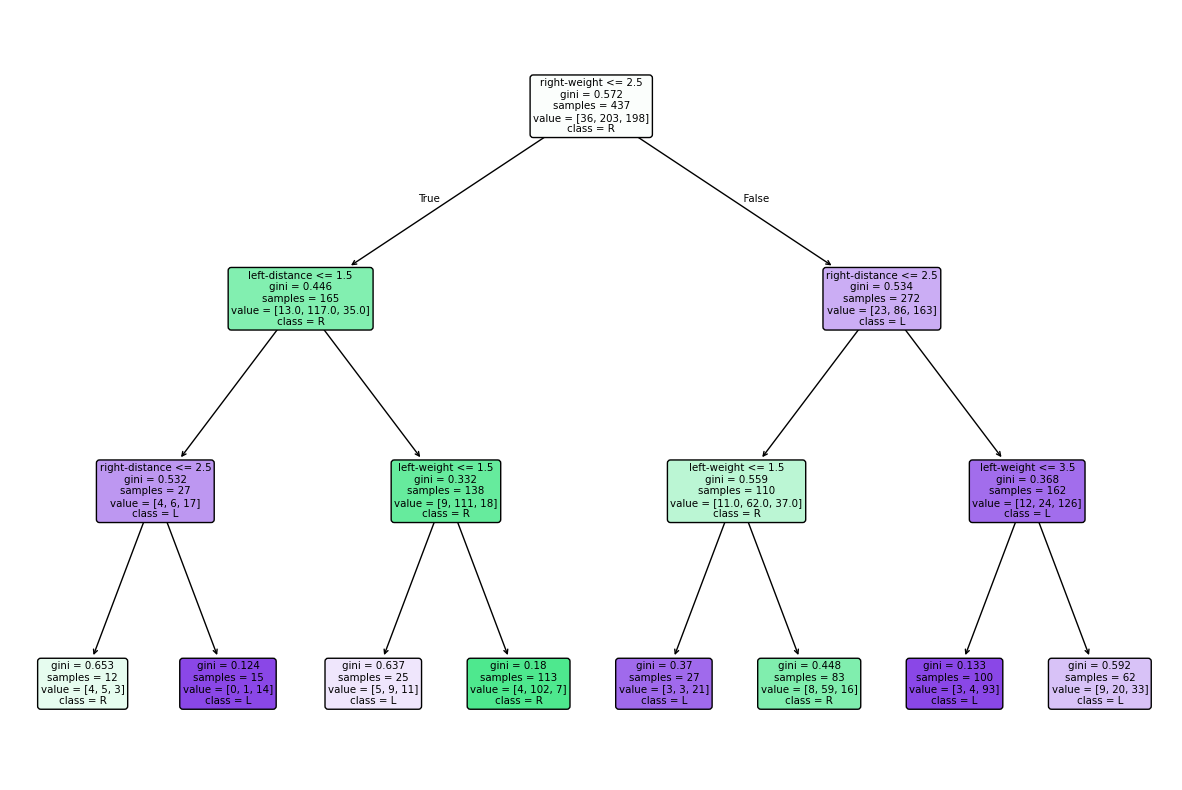

Decision Tree of Gini Index:  None


In [20]:
decision_tree1 = plot_decision_tree(clf_object_gini, feature_names, class_names)
print("Decision Tree of Gini Index: ", decision_tree1)

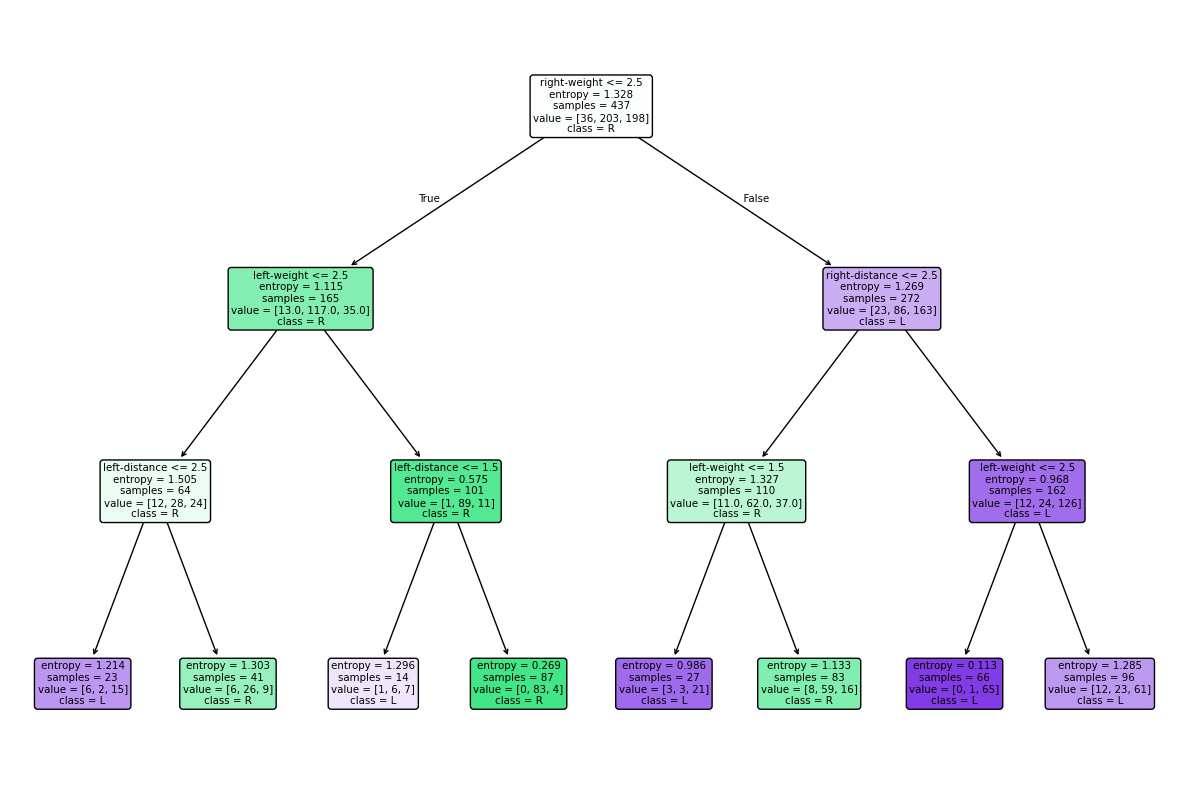

Decision Tree of Entropy:  None


In [21]:
decision_tree2 = plot_decision_tree(clf_object_entropy, feature_names, class_names)
print("Decision Tree of Entropy: ", decision_tree2)

#### Step 9: Train, Predict and Evaluate Models

* Load and split the dataset into training and testing sets.
* Train classifiers using Gini and Entropy criteria.
* Make predictions on the test set and evaluate accuracy using confusion matrix, accuracy score and classification report.

In [22]:
if __name__ == "__main__":

    data = importdata()
    X, Y, X_train, X_test, y_train, y_test = splitdataset(data)


    print("\n----- Training Using Gini -----")
    clf_gini = train_using_gini(X_train, y_train)
    y_pred_gini = prediction(X_test, clf_gini)
    cal_accuracy(y_test, y_pred_gini)

    
    print("\n----- Training Using Entropy -----")
    clf_entropy = train_using_entropy(X_train, y_train)
    y_pred_entropy = prediction(X_test, clf_entropy)
    cal_accuracy(y_test, y_pred_entropy)

Dataset Length: 625
Dataset Shape: (625, 5)
Dataset Head:
   class  left-weight  left-distance  right-weight  right-distance
0     B            1              1             1               1
1     R            1              1             1               2
2     R            1              1             1               3
3     R            1              1             1               4
4     R            1              1             1               5

----- Training Using Gini -----
Predicted Values:
 ['R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L'
 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'L' 'R'
 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'R

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

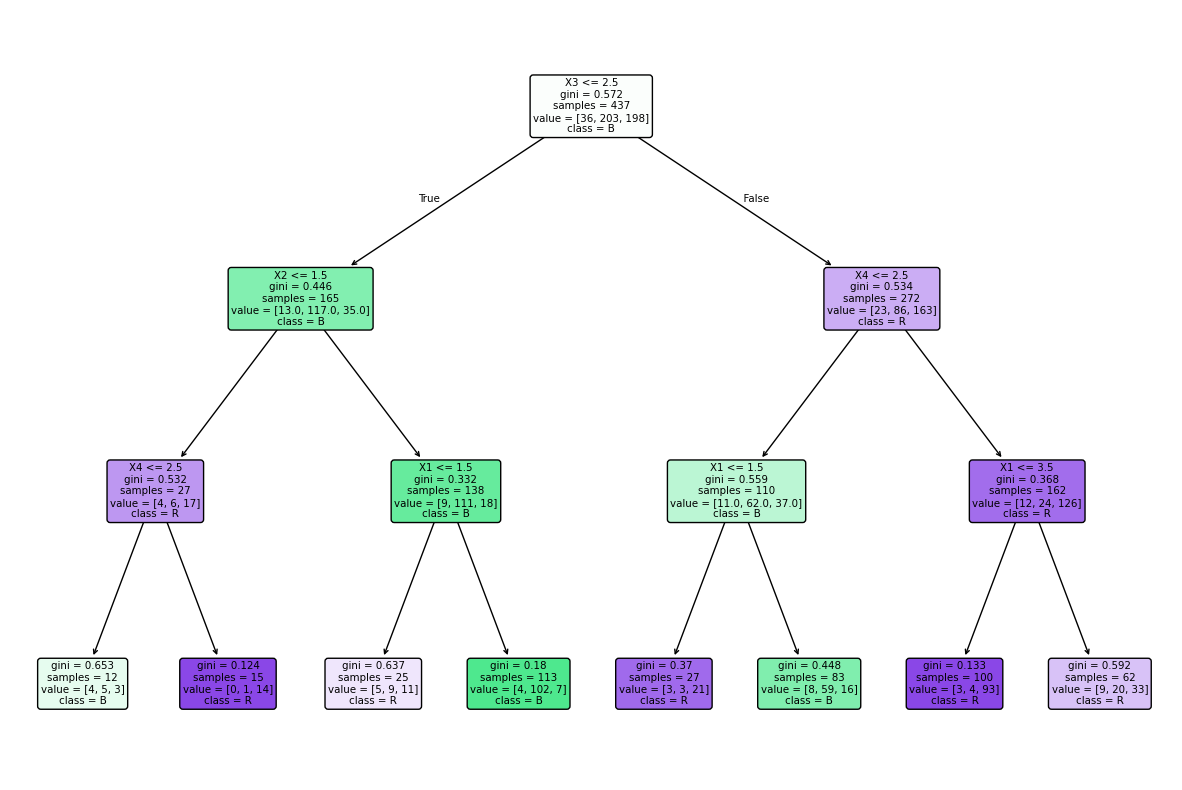

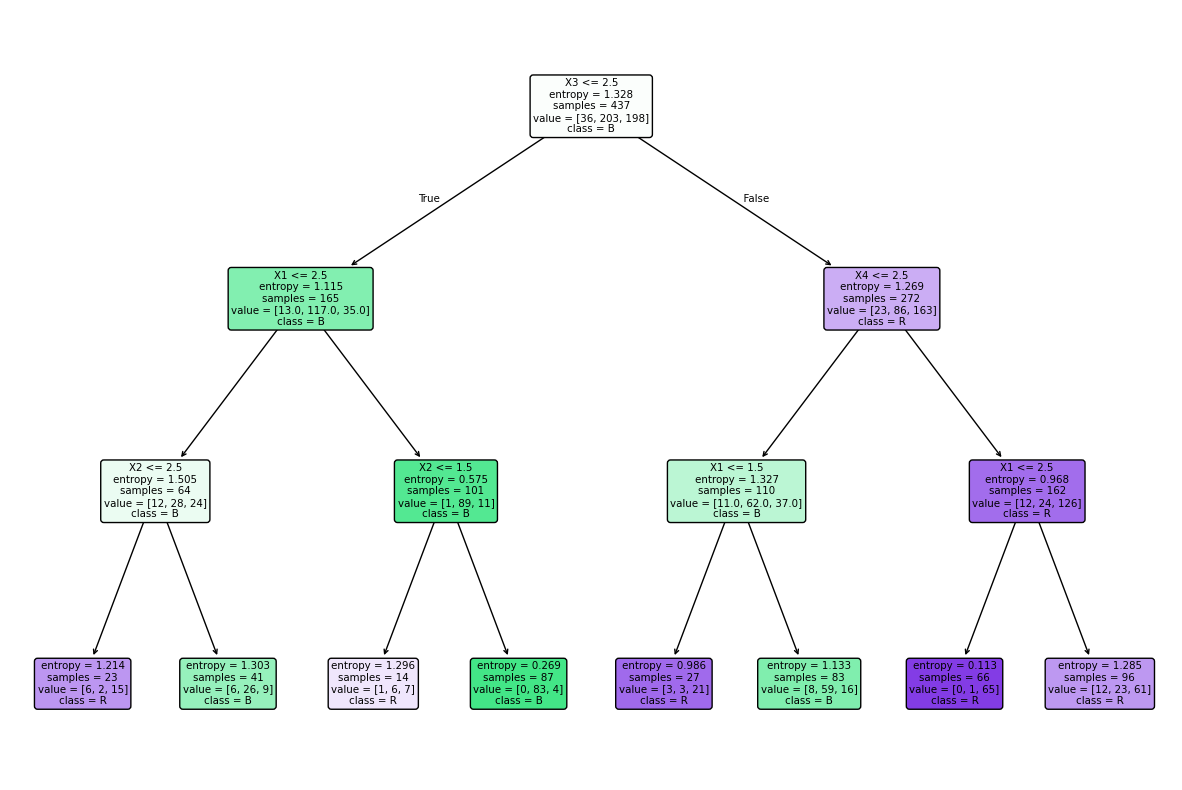

In [23]:
plot_decision_tree(clf_gini, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])

plot_decision_tree(clf_entropy, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])